# Feature Engine - Topic 05 - Handle Variable Discretisation

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%202%20-%20Unit%20Objective.png">

##  Topic Objectives

* Handle Variable Discretisation using Equal Frequency discretiser, Equal Width discretiser or Arbitrary discretiser

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%204%20-%20Import%20Package%20for%20Learning.png"> 

## Import Packages for Learning

And load our typical packages.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
from sklearn.pipeline import Pipeline

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

## Handle Variable Discretization

This technique consists of transforming continuous numerical variables into discrete variables. The discrete variables will contain intervals related to the numerical distribution. The interval will be decided based on the frequency or width. We will study:
* EqualFrequencyDiscretiser
* EqualWidthDiscretiser
* ArbitraryDiscretiser

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

When should I consider using them? We can consider these use cases:
* When your feature has an abnormal or weird numerical distribution, and by discretizing this variable, the categorical distribution is better understood by the model
* You have a continuous target variable, and you are not successful in fitting a model to the dataset. Then, you can discretize the target variable and convert the ML task to classification since your target variable is now categorical. The expectation is that we will create more conditions to find a model that fits the data.

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

#### Equal Frequency

It divides continuous numerical variables into contiguous equal frequency intervals, intervals containing approximately the same proportion of observations. The function documentation is found [here](https://feature-engine.trainindata.com/en/latest/user_guide/discretisation/EqualFrequencyDiscretiser.html)
* The arguments are `variables` to apply the method; if you don't specify a variable, it will select all numerical variables. And `q` (for quantiles), which is the desired number of equal frequency intervals (or quantiles).

In [2]:
from feature_engine.discretisation import EqualFrequencyDiscretiser

We will use the target variable from the California Housing dataset.

In [3]:
from sklearn.datasets import fetch_openml
california_data = fetch_openml(data_id=44977, as_frame=True)  # california_housing on OpenML
df = pd.DataFrame(california_data.data,columns=california_data.feature_names)
df['target'] = pd.Series(california_data.target)
df.head()

,longitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome,target
0,-122.23,37.88,41,880,129,322,126,8.3252,452600.0
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014,358500.0
2,-122.24,37.85,52,1467,190,496,177,7.2574,352100.0
3,-122.25,37.85,52,1274,235,558,219,5.6431,341300.0
4,-122.25,37.85,52,1627,280,565,259,3.8462,342200.0


We assess the distribution with sns.histplot()

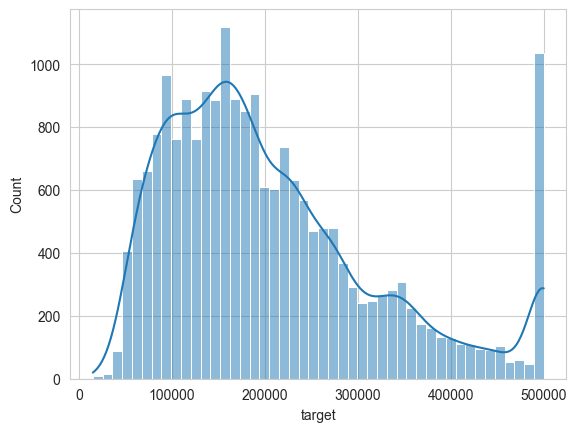

In [4]:
sns.histplot(data=df, x='target', kde=True)
plt.show()

We create a pipeline with `EqualFrequencyDiscretiser()` on the target variable and look for five bins. We then `.fit_transform()` the data
* In the workplace, you will review business criteria to select a number for ``q``. Typically, it will be between 3 to 6. Alternatively, you can run multiple simulations and assess the results for numerous ``q``


In [5]:
pipeline = Pipeline([
    ('efd', EqualFrequencyDiscretiser(q=5, variables=['target'] ))
])

df_transformed = pipeline.fit_transform(df)

We assess the `efd` step and check what bins the transformer calculated using `.binner_dict_`

In [6]:
pipeline['efd'].binner_dict_

{'target': [-inf,
  np.float64(107200.0),
  np.float64(157300.0),
  np.float64(209400.0),
  np.float64(290000.0),
  inf]}

Finally, we plot the new target distribution. As expected, all intervals have the same frequency
* Note in the plot the bar where the target is zero; it corresponds to the numerical interval of -inf to 15.3. You can extend this for the remaining bars

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

The upside of using this technique, considering you are using the target variable, is that your target variable for the classification task will be already balanced, which means the labels have similar frequencies.

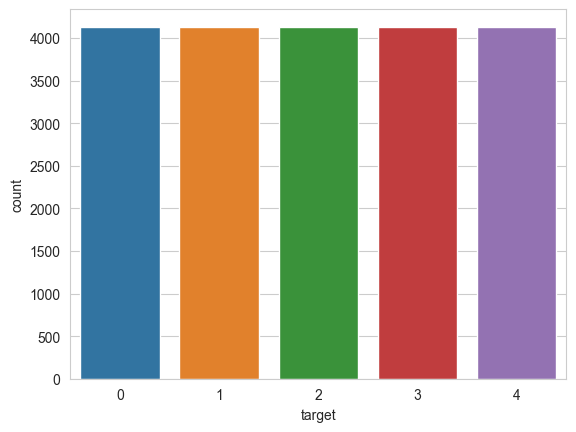

In [7]:
sns.countplot(data=df_transformed, x='target', palette='tab10', hue='target', legend=False)
plt.show()

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png">

#### Equal Width

This technique divides continuous numerical variables into intervals of the same width. Note that the count of observations per interval may vary. The function documentation is found [here](https://feature-engine.trainindata.com/en/latest/user_guide/discretisation/EqualWidthDiscretiser.html).
* The arguments are `variables` to apply the method to; if you don't parse anything, it will select all numerical variables. And `bins`, which is the number of equal-width intervals/bins you want.

In [8]:
from feature_engine.discretisation import EqualWidthDiscretiser

We will use the target variable from the California Housing dataset.

In [9]:
california_data = fetch_openml(data_id=44977, as_frame=True)  # california_housing on OpenML
df = pd.DataFrame(california_data.data,columns=california_data.feature_names)
df['target'] = pd.Series(california_data.target)
df.head()

,longitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome,target
0,-122.23,37.88,41,880,129,322,126,8.3252,452600.0
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014,358500.0
2,-122.24,37.85,52,1467,190,496,177,7.2574,352100.0
3,-122.25,37.85,52,1274,235,558,219,5.6431,341300.0
4,-122.25,37.85,52,1627,280,565,259,3.8462,342200.0


We assess its distribution.

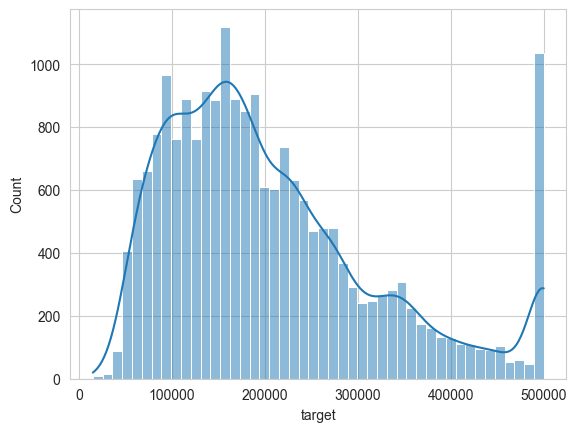

In [10]:
sns.histplot(data=df, x='target', kde=True)
plt.show()

In [11]:
pipeline = Pipeline([
      ('ewd', EqualWidthDiscretiser(bins=6, variables=['target']) )
])

df_transformed = pipeline.fit_transform(df)

We assess the `ewd` step and check what bins the transformer calculated using `.binner_dict_`

In [12]:
pipeline['ewd'].binner_dict_

{'target': [-inf,
  np.float64(95832.66666666667),
  np.float64(176666.33333333334),
  np.float64(257500.0),
  np.float64(338333.6666666667),
  np.float64(419167.3333333334),
  inf]}

Finally, we plot the new target distribution. As expected, all intervals have the same width (7.5)
* Note in the plot, the bar where the target is zero corresponds to the numerical interval of -inf to 12.5.  You can extend this for the remaining bars

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

The downside of using this technique, if you are using the target variable, is that the target variable for the classification task is likely not balanced.

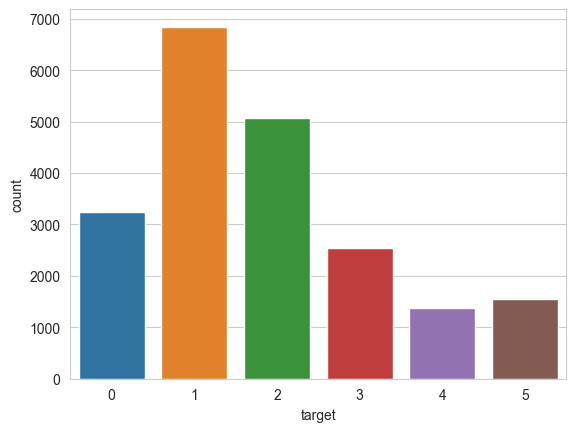

In [13]:
sns.countplot(data=df_transformed, x='target', palette='tab10', hue='target', legend=False)
plt.show()

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png">

####  Arbitrary Discretiser

It divides continuous range intervals, which limits are determined by the user. The documentation is found [here](https://feature-engine.trainindata.com/en/latest/user_guide/discretisation/ArbitraryDiscretiser.html). The used argument is:
* ``binning_dict`` is a dictionary that tells which variable you want to apply the method and the intervals.

* You may use this technique when the client has a standard predefined way to map the numerical values to ranges. For example, imagine if the variable is Revenue from a given purchase. The business is comfortable assuming that Revenue smaller than 100 is small, between 100 and 1000 is medium and greater than 1000 is big. You can also conduct separate analyses with other custom ranges to question current assumptions and/or look for other criteria to discretise the data.

In [14]:
from feature_engine.discretisation import ArbitraryDiscretiser

We will use the target variable from the California Housing dataset.

In [15]:
california_data = fetch_openml(data_id=44977, as_frame=True)  # california_housing on OpenML
df = pd.DataFrame(california_data.data,columns=california_data.feature_names)
df['target'] = pd.Series(california_data.target)
df.head()

,longitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome,target
0,-122.23,37.88,41,880,129,322,126,8.3252,452600.0
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014,358500.0
2,-122.24,37.85,52,1467,190,496,177,7.2574,352100.0
3,-122.25,37.85,52,1274,235,558,219,5.6431,341300.0
4,-122.25,37.85,52,1627,280,565,259,3.8462,342200.0


We assess its distribution.

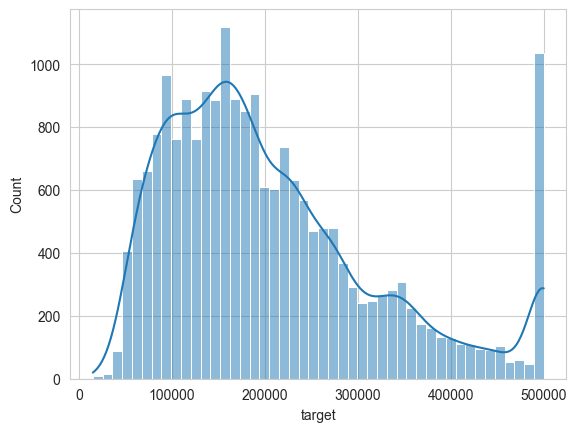

In [16]:
sns.histplot(data=df, x='target', kde=True)
plt.show()

We create a pipeline with `ArbitraryDiscretiser()` on the target variable and look for four custom bins. We then `.fit_transform()` the data
* In the workplace, you will work with the client to select the number of `bins`. Typically, it might be between 3 to 6. However, you can run multiple simulations and assess the results for numerous `bins`

In [17]:
import numpy as np # we import NumPy to set -inf and +inf
pipeline = Pipeline([
      ( 'arbd', ArbitraryDiscretiser(binning_dict={'target':[-np.inf,1,2,4,np.inf]}) )
])

df_transformed = pipeline.fit_transform(df)

We assess the arbd step and check the bins we created with `.binner_dict_`

In [18]:
pipeline['arbd'].binner_dict_

{'target': [-inf, 1, 2, 4, inf]}

Finally, we plot the new target distribution.
* Note in the plot the bar where the target is zero corresponds to the numerical interval of -inf to 10.  You can extend this for the remaining bars

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

The upside of this technique is that we set the intervals we are comfortable with. The downside is that the categorical distribution may be imbalanced.

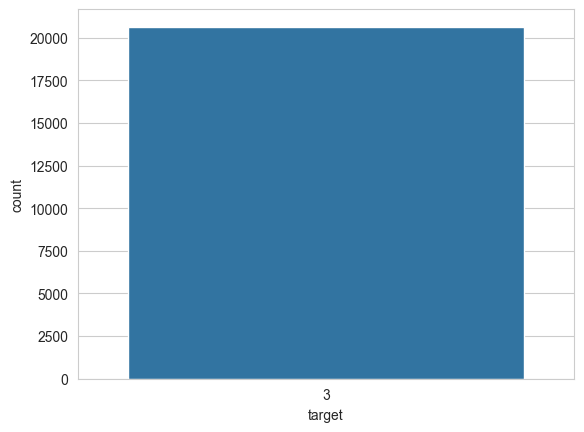

In [19]:
sns.countplot(data=df_transformed, x='target', palette='tab10', hue='target', legend=False)
plt.show()